In [1]:
import numpy as np

from collections import deque, namedtuple

import matplotlib.pyplot as plt

import itertools
import random
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Gym
import gymnasium as gym
import icu_sepsis

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
env = gym.make('Sepsis/ICU-Sepsis-v2')
state, info = env.reset()
print('Initial state:', state)
print('Extra info:', info)

next_state, reward, terminated, truncated, info = env.step(0)
print('\nTaking action 0:')
print('Next state:', next_state)
print('Reward:', reward)
print('Terminated:', terminated)
print('Truncated:', truncated)

Initial state: 163
Extra info: {'admissible_actions': [0], 'state_vector': array([ 0.00649351, -0.3961039 , -0.5       ,  0.61948052, -0.85235959,
       -0.07954431,  0.14064341, -0.27191158,  2.00969829,  2.32218053,
        2.28884607, -0.71640739, -0.0753267 , -0.28304186,  0.57571812,
       -0.17081641, -0.80846072, -0.25741847,  0.16550841,  0.71918382,
       -0.01785015, -0.48645683,  0.03681447, -0.26841785, -0.06784961,
        0.08831407, -0.07002254,  0.07629122,  0.14090842,  0.22270556,
        0.11222898,  0.22302699, -0.60998418, -1.15407605,  0.08653186,
       -0.00683591,  0.2188018 ,  0.66915603,  2.19668373, -0.17064771,
       -0.26217596, -0.36193771, -0.05873175, -0.5367412 , -3.00886387,
       -1.82357005, -1.79432308]), 'sofa_score': np.float64(6.93312101910828)}

Taking action 0:
Next state: 15
Reward: 0.0
Terminated: False
Truncated: False


In [5]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.feature_layer = nn.Sequential(
            nn.Linear(s_size, h_size),
            nn.LeakyReLU(0.5),
            nn.BatchNorm1d(h_size),
            nn.Linear(h_size, h_size),
            nn.LeakyReLU(0.5),
            nn.BatchNorm1d(h_size),
        )

        self.value_stream = nn.Linear(h_size, 1)
        self.advantage_stream = nn.Linear(h_size, a_size)

    def forward(self, state):
        features = self.feature_layer(state)
        # Value V(s)
        V = self.value_stream(features)
        # Advantage A(s, a)
        A = self.advantage_stream(features)
        # Q(s, a)
        Q = V + (A - A.mean(dim=1, keepdim=True))
        return Q

In [7]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done', 'prev_action'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)
        self.transition = Transition

    def __len__(self):
        return len(self.memory)

    def push(self, *args):
        self.memory.append(self.transition(*args))

    def sample(self, b_size):
        if len(self.memory) < b_size:
            return None
        return random.sample(self.memory, b_size)

In [9]:
class DQNAgent:
    def __init__(self, s_size, a_size, h_size, gamma, lr, buffer_capacity, b_size, print_every, device):
        self.s_size = s_size
        self.a_size = a_size
        self.h_size = h_size
        self.gamma = gamma
        self.lr = lr
        self.b_size = b_size
        self.print_every = print_every
        self.device = device
        self.train_step_count = 0

        # Policy and Target Network
        self.policy_net = Policy(s_size, a_size, h_size).to(device)
        self.target_net = Policy(s_size, a_size, h_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer and Loss
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr)
        self.criterion = nn.SmoothL1Loss()

        # Replay Buffer
        self.memory = ReplayBuffer(buffer_capacity)

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            # Exploration: Choose a random admissible action
            return random.randrange(self.a_size)
        else:
            # Exploitation: Choose the action with the maximum Q-value
            self.policy_net.eval()
            with torch.no_grad():
                state_one_hot = torch.zeros(1, self.s_size, device=self.device)
                state_one_hot[0, state] = 1.0
                q_values = self.policy_net(state_one_hot)
                action = q_values.argmax().item()
            self.policy_net.train()
            
            return action

    def _convert_batch_to_tensors(self, transitions):
        batch = self.memory.transition(*zip(*transitions))

        # Convert discrete state indices
        s_batch = torch.zeros(len(transitions), self.s_size, device=self.device)
        next_s_batch = torch.zeros(len(transitions), self.s_size, device=self.device)

        for i, s_idx in enumerate(batch.state):
            s_batch[i, s_idx] = 1.0
        for i, s_idx in enumerate(batch.next_state):
            # Only set next state if not terminal
            if not batch.done[i]:
                next_s_batch[i, s_idx] = 1.0

        # Convert other components
        a_batch = torch.tensor(batch.action, dtype=torch.long, device=self.device).unsqueeze(1)
        r_batch = torch.tensor(batch.reward, dtype=torch.float, device=self.device).unsqueeze(1)
        done_mask = torch.tensor(batch.done, dtype=torch.float, device=self.device).unsqueeze(1)
        prev_action_batch = torch.tensor(batch.prev_action, dtype=torch.long, device=self.device).unsqueeze(1)

        return s_batch, a_batch, r_batch, next_s_batch, done_mask, prev_action_batch

    def learn(self):
        transitions = self.memory.sample(self.b_size)
        if transitions is None:
            return

        s_batch, a_batch, r_batch, next_s_batch, done_mask, _ = self._convert_batch_to_tensors(transitions)

        # Q(s_t, a_t)
        q_values = self.policy_net(s_batch).gather(1, a_batch)

        # V(s_(t+1)) = max_a Q_target(s_(t+1), a)
        with torch.no_grad():
            next_q_values = self.target_net(next_s_batch).max(1)[0].unsqueeze(1)

        # target_q_values = R_t + gamma * V(s_(t+1)) * (1 - done_mask)
        target_q_values = r_batch + self.gamma * next_q_values * (1 - done_mask) # mask 'done' states

        # Huber Loss
        loss = self.criterion(q_values, target_q_values)

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_value_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # Update Target Network
        self.train_step_count += 1
        if self.train_step_count % self.print_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

In [11]:
def calculate_penalty(curr_action, prev_action, delta_max):
    if prev_action == -1:
        return 0.0

    vp_prev = prev_action // 5
    iv_prev = prev_action % 5
    vp_curr = curr_action // 5
    iv_curr = curr_action % 5

    # Calculate absolute change in dosage levels
    delta_vp = abs(vp_curr - vp_prev)
    delta_iv = abs(iv_curr - iv_prev)
    penalty = 0.0

    if delta_vp > delta_max or delta_iv > delta_max:
        penalty = 1.0

    return penalty

In [13]:
class ConstrainedDQNAgent(DQNAgent):
    def __init__(self, delta_max, lambda_penalty, **kwargs):
        super().__init__(**kwargs)
        self.delta_max = delta_max
        self.lambda_penalty = lambda_penalty

    def learn(self):
        transitions = self.memory.sample(self.b_size)
        if transitions is None:
            return

        state_batch, action_batch, reward_batch, next_state_batch, done_mask, prev_action_batch = self._convert_batch_to_tensors(transitions)

        penalties = torch.zeros_like(reward_batch, device=self.device)
        for i in range(self.b_size):
            curr_action_int = action_batch[i].item()
            prev_action_int = prev_action_batch[i].item()
            
            penalty_val = calculate_penalty(curr_action_int, prev_action_int, self.delta_max)
            penalties[i] = penalty_val

        # R(s,t) = R_original(s_t, a_t) - λ * Penalty(a_t, a_(t-1))
        final_reward_batch = reward_batch - self.lambda_penalty * penalties

        # Q(s_t, a_t)
        current_q_values = self.policy_net(state_batch).gather(1, action_batch)

        # V(s_(t+1)) = max_a Q_target(s_(t+1), a) - DQN
        with torch.no_grad():
            next_q_values = self.target_net(next_state_batch).max(1)[0].unsqueeze(1)

        target_q_values = final_reward_batch + self.gamma * next_q_values * (1 - done_mask)

        # Optimize
        loss = self.criterion(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_value_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        # Update Target Network
        self.train_step_count += 1
        if self.train_step_count % self.print_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

In [15]:
def train_agent(env, agent, n_episodes, epsilon_start, epsilon_end, epsilon_decay_steps):
    history = {
        'episode_rewards': [],
        'episode_lengths': [],
        'losses': [],
        'avg_rewards': [],
        'constraint_violations': []
    }

    epsilon = epsilon_start
    epsilon_step_size = (epsilon_start - epsilon_end) / epsilon_decay_steps

    print(f"Starting training for {n_episodes} episodes...")

    for i_episode in tqdm(range(1, n_episodes + 1)):
        state, info = env.reset()
        total_reward = 0
        episode_length = 0
        done = False
        step_loss = 0
        
        prev_action = -1 
        total_violations = 0
        total_steps = 0

        for t in itertools.count():
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Check for constraint violation
            if isinstance(agent, ConstrainedDQNAgent):
                penalty_val = calculate_penalty(action, prev_action, agent.delta_max)
                if penalty_val > 0:
                    total_violations += 1

            # Store transition
            agent.memory.push(state, action, reward, next_state, done, prev_action)

            # Perform one step
            loss = agent.learn()
            if loss is not None:
                step_loss = loss

            prev_action = action
            state = next_state
            total_reward += reward
            episode_length += 1
            total_steps += 1

            if done:
                break

        # Decay epsilon
        if i_episode < epsilon_decay_steps:
            epsilon = max(epsilon_end, epsilon - epsilon_step_size)

        # Log training progress
        history['episode_rewards'].append(total_reward)
        history['episode_lengths'].append(episode_length)
        history['losses'].append(step_loss)
        if isinstance(agent, ConstrainedDQNAgent):
             history['constraint_violations'].append(total_violations / total_steps if total_steps > 0 else 0)

        # Calculate average reward over the last 100 episodes
        avg_reward = np.mean(history['episode_rewards'][-100:])
        history['avg_rewards'].append(avg_reward)

        if i_episode % 100 == 0:
            print(f"\nEpisode {i_episode}/{n_episodes} | Avg Reward (100) = {avg_reward:.2f} | Epsilon: {epsilon:.4f}")
            if isinstance(agent, ConstrainedDQNAgent):
                avg_violations = np.mean(history['constraint_violations'][-100:])
                print(f"| Avg Violation Rate (100) = {avg_violations:.4f}")


    print("Training complete.")
    return history

In [17]:
def evaluate_policy(env, agent, n_test_episodes):
    survival_rewards = []
    action_frequencies = {a: 0 for a in range(agent.a_size)}
    total_steps = 0
    total_violations = 0

    print(f"\nStarting evaluation for {n_test_episodes} test episodes...")

    for i_episode in tqdm(range(n_test_episodes)):
        state, info = env.reset()
        total_reward = 0
        done = False
        prev_action = -1

        while not done:
            # Select action with epsilon=0
            action = agent.select_action(state, 0.0)

            if isinstance(agent, ConstrainedDQNAgent):
                penalty_val = calculate_penalty(action, prev_action, agent.delta_max)
                if penalty_val > 0:
                    total_violations += 1

            action_frequencies[action] += 1
            total_steps += 1

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = next_state

            prev_action = action
            state = next_state

        survival_rewards.append(total_reward)

    survival_rate = np.mean([r > 0 for r in survival_rewards]) # Survival reward is +15, death is -15

    # Normalize action frequencies for plotting
    a_probs = {k: v / total_steps for k, v in action_frequencies.items()}
    violation_rate = total_violations / total_steps if total_steps > 0 else 0.0

    print(f"\n--- Evaluation Results ---")
    print(f"Estimated Patient Survival Rate: {survival_rate * 100:.2f}%")
    print(f"Mean Episode Reward: {np.mean(survival_rewards):.2f}")
    if isinstance(agent, ConstrainedDQNAgent):
         print(f"Constraint Violation Rate (Delta Max {agent.delta_max}): {violation_rate * 100:.2f}%")
    print(f"Total Actions Taken: {total_steps}")

    return survival_rate, a_probs

In [19]:
def plot_results(history, a_probs, survival_rate):
    # Learning Curve
    plt.figure(figsize=(10, 6))
    plt.plot(history['avg_rewards'], label='Avg Episode Reward (100-Episode Window)', color='darkorange')
    plt.title('DQN Learning Curve on ICU-Sepsis')
    plt.xlabel('Episode')
    plt.ylabel('Average Total Reward')
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.show()
    
    # The action space is 5x5: IV Fluid (0-4) x Vasopressor (0-4)
    # a_index: VP_dose * 5 + IV_dose
    # IV_dose: 0, 1, 2, 3, 4
    # VP_dose: 0, 1, 2, 3, 4
    heatmap_data = np.zeros((5, 5))
    for a_index, prob in a_probs.items():
        if a_index < 25:
            vp_dose = a_index // 5
            iv_dose = a_index % 5
            heatmap_data[vp_dose, iv_dose] = prob

    # Action Distribution Heatmap
    plt.figure(figsize=(8, 7))
    plt.imshow(heatmap_data, cmap='viridis', origin='lower')
    plt.colorbar(label='Probability')
    plt.title('Trained Constrained DQN Action Distribution')
    plt.xlabel('IV Fluid Dose (Discretized Level 0-4)')
    plt.ylabel('Vasopressor Dose (Discretized Level 0-4)')
    plt.xticks(np.arange(5))
    plt.yticks(np.arange(5))
    plt.gca().invert_yaxis() # VP 4 at the top
    plt.text(4.5, 4.5, f"Survival: {survival_rate*100:.2f}%", ha='right', va='bottom', fontsize=10, color='white', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3'))
    plt.show()

    # Loss Curve
    plt.figure(figsize=(10, 3))
    plt.plot(history['losses'], label='Training Loss (Huber)', color='cornflowerblue', alpha=0.7)
    plt.title('DQN Training Loss per Step')
    plt.xlabel('Training Step (Smoothed)')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.5)
    plt.ylim(bottom=0)
    plt.legend()
    plt.show()

    # Constraint Violation Rate
    if 'constraint_violations' in history and history['constraint_violations']:
        plt.figure(figsize=(10, 3))
        plt.plot(history['constraint_violations'], label='Avg Constraint Violation Rate (per step)', color='red', alpha=0.7)
        plt.title(f'Constraint Violation Rate During Training ($\Delta_{{max}}={agent.delta_max}, \lambda={agent.lambda_penalty}$)')
        plt.xlabel('Episode')
        plt.ylabel('Violation Rate (Smoothed)')
        plt.grid(True, alpha=0.5)
        plt.legend()
        plt.show()

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [23]:
sepsis_hyperparameters = {
    "s_size": env.observation_space.n, # 716
    "a_size": env.action_space.n,      # 25
    "h_size": 128,
    "gamma": 0.999,
    "lr": 1e-5,
    "buffer_capacity": 100000,
    "b_size": 64,
    "print_every": 200,
    "device": device
}

In [25]:
training_hyperparameters = {
    "n_episodes": 20000,
    "epsilon_start": 1.0,
    "epsilon_end": 0.05,
    "epsilon_decay_steps": 4000,

    "n_test_episodes": 1000
}

In [27]:
agent = DQNAgent(sepsis_hyperparameters["s_size"], sepsis_hyperparameters["a_size"], sepsis_hyperparameters["h_size"], sepsis_hyperparameters["gamma"], sepsis_hyperparameters["lr"], sepsis_hyperparameters["buffer_capacity"], sepsis_hyperparameters["b_size"], sepsis_hyperparameters["print_every"], sepsis_hyperparameters["device"])

In [29]:
training_history = train_agent(env, agent, training_hyperparameters["n_episodes"], training_hyperparameters["epsilon_start"], training_hyperparameters["epsilon_end"], training_hyperparameters["epsilon_decay_steps"])

Starting training for 20000 episodes...


  0%|▏                                      | 98/20000 [00:01<03:15, 101.93it/s]


Episode 100/20000 | Avg Reward (100) = 0.76 | Epsilon: 0.9762


  1%|▍                                      | 203/20000 [00:02<04:08, 79.52it/s]


Episode 200/20000 | Avg Reward (100) = 0.82 | Epsilon: 0.9525


...


Episode 19800/20000 | Avg Reward (100) = 0.71 | Epsilon: 0.0502


100%|████████████████████████████████████▊| 19915/20000 [04:41<00:01, 75.01it/s]


Episode 19900/20000 | Avg Reward (100) = 0.77 | Epsilon: 0.0502


100%|█████████████████████████████████████| 20000/20000 [04:43<00:00, 70.65it/s]


Episode 20000/20000 | Avg Reward (100) = 0.79 | Epsilon: 0.0502
Training complete.


In [31]:
survival_rate, a_probs = evaluate_policy(env, agent, training_hyperparameters["n_test_episodes"])


Starting evaluation for 1000 test episodes...


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1146.63it/s]


--- Evaluation Results ---
Estimated Patient Survival Rate: 75.20%
Mean Episode Reward: 0.75
Total Actions Taken: 9220


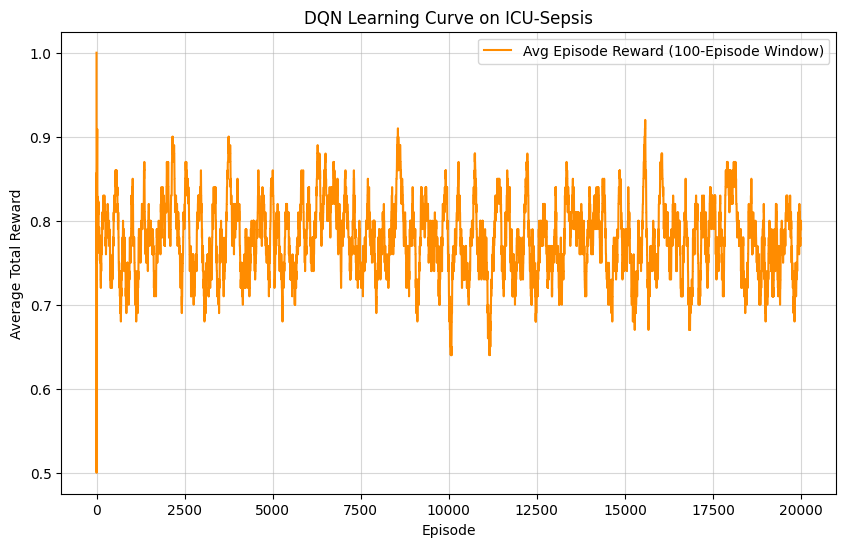

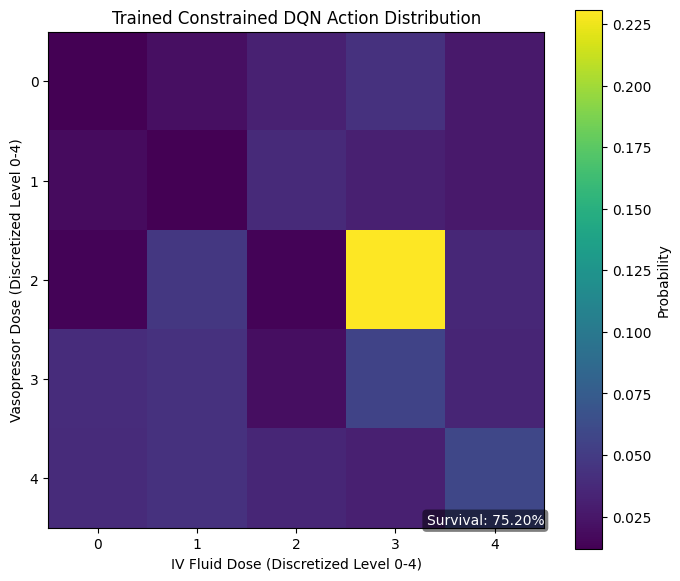

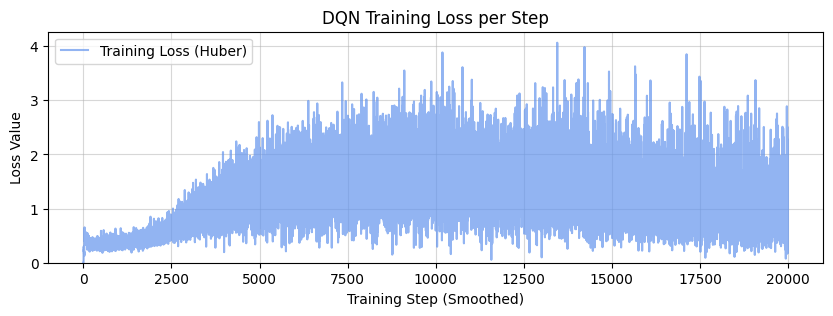

In [33]:
plot_results(training_history, a_probs, survival_rate)

In [35]:
env.close()

In [101]:
agent = ConstrainedDQNAgent(**sepsis_hyperparameters, delta_max=1, lambda_penalty=1)

In [103]:
training_history = train_agent(env, agent, training_hyperparameters["n_episodes"], training_hyperparameters["epsilon_start"], training_hyperparameters["epsilon_end"], training_hyperparameters["epsilon_decay_steps"])

Starting training for 20000 episodes...


  1%|▏                                      | 103/20000 [00:01<04:01, 82.40it/s]


Episode 100/20000 | Avg Reward (100) = 0.80 | Epsilon: 0.9762
| Avg Violation Rate (100) = 0.5269


  1%|▍                                      | 208/20000 [00:02<04:34, 72.03it/s]


Episode 200/20000 | Avg Reward (100) = 0.86 | Epsilon: 0.9525
| Avg Violation Rate (100) = 0.5596


...


Episode 19800/20000 | Avg Reward (100) = 0.83 | Epsilon: 0.0502
| Avg Violation Rate (100) = 0.2073


100%|████████████████████████████████████▊| 19913/20000 [04:40<00:01, 71.07it/s]


Episode 19900/20000 | Avg Reward (100) = 0.82 | Epsilon: 0.0502
| Avg Violation Rate (100) = 0.1904


100%|█████████████████████████████████████| 20000/20000 [04:42<00:00, 70.89it/s]


Episode 20000/20000 | Avg Reward (100) = 0.76 | Epsilon: 0.0502
| Avg Violation Rate (100) = 0.1710
Training complete.


In [105]:
survival_rate, a_probs = evaluate_policy(env, agent, training_hyperparameters["n_test_episodes"])


Starting evaluation for 1000 test episodes...


100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 1119.33it/s]


--- Evaluation Results ---
Estimated Patient Survival Rate: 76.80%
Mean Episode Reward: 0.77
Constraint Violation Rate (Delta Max 1): 13.97%
Total Actions Taken: 8825


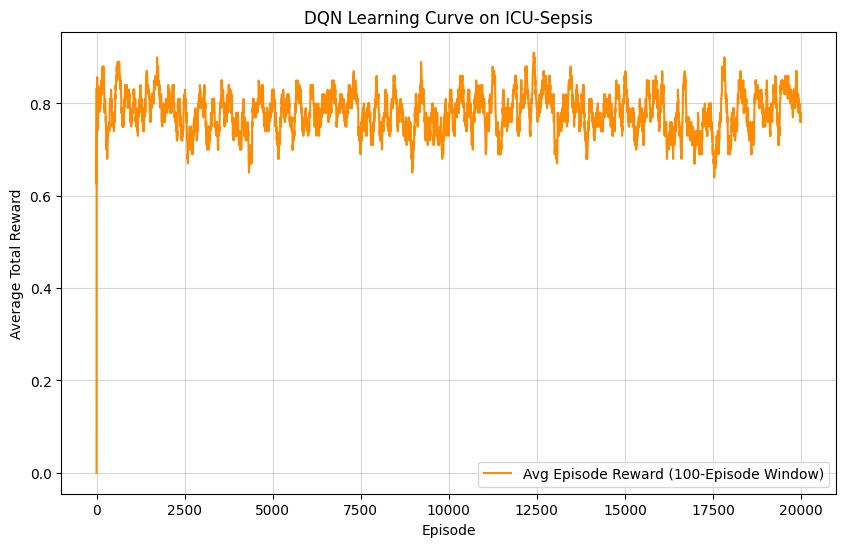

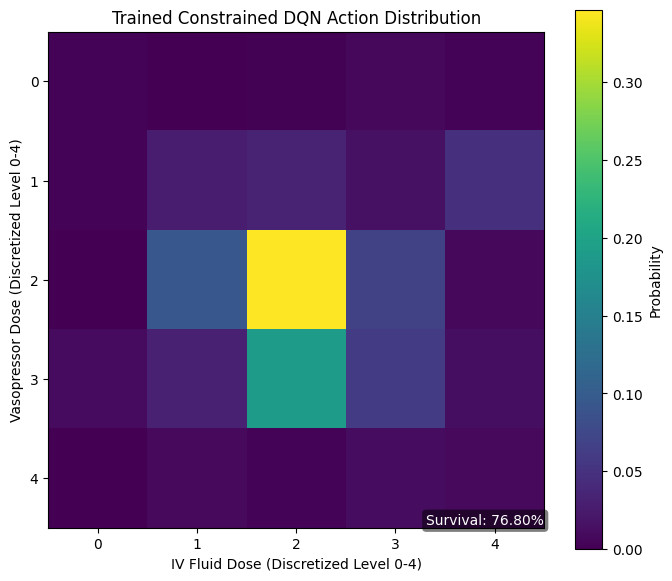

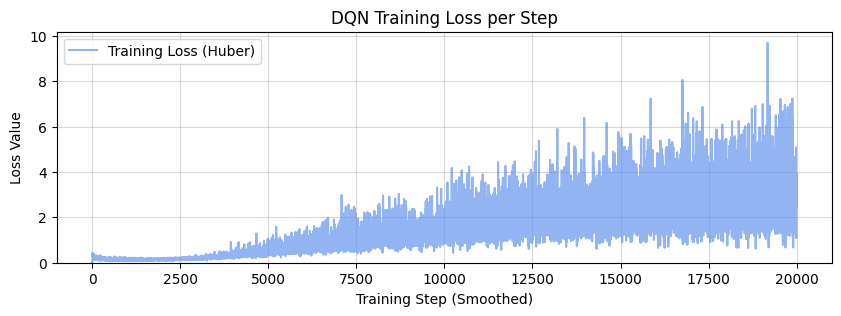

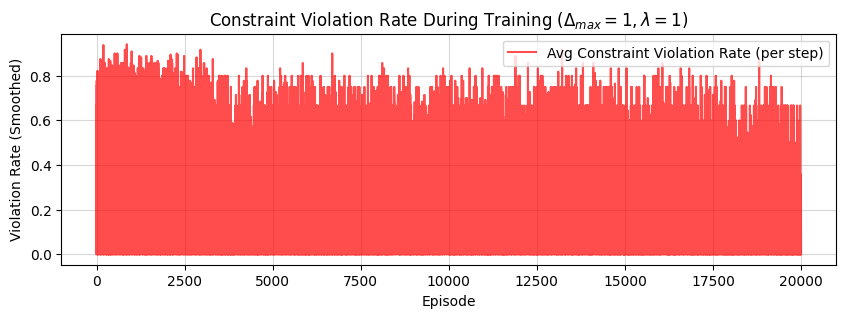

In [107]:
plot_results(training_history, a_probs, survival_rate)

In [109]:
env.close()